In [63]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn as sk
import statsmodels.api as sm

In [64]:
# Set parameters and read cvs / tsv files
NUM_PARTICIPANTS = 88
REG_FREQS = list(pd.read_csv("data/classes.csv"))

participants = pd.read_csv("data/participants.tsv", sep="\t")
data = pd.DataFrame(columns=["id", "age"] + REG_FREQS)

# Extract data matrix
for i in range(NUM_PARTICIPANTS):
    fpath = f"data/Features_sub-{(i + 1):03}@rawsub-{(i + 1):03}_task-eyesclosed_eeg_notch_high_Average_referenceDataset004504_{i // 30 + 1}.csv"
    if (os.path.exists(fpath)):
        fdata = pd.read_csv(fpath)
        data.loc[len(data)] = [i + 1, participants.at[i, "Age"]] + fdata.iloc[0].tolist()

In [65]:
# Verify data imported correctly
data

,id,age,bankssts L -delta,bankssts L -theta,bankssts L -alpha,bankssts L -beta,bankssts L -gamma1,bankssts L -gamma2,bankssts R -delta,bankssts R -theta,...,transversetemporal L -alpha,transversetemporal L -beta,transversetemporal L -gamma1,transversetemporal L -gamma2,transversetemporal R -delta,transversetemporal R -theta,transversetemporal R -alpha,transversetemporal R -beta,transversetemporal R -gamma1,transversetemporal R -gamma2
0,1.0,57.0,0.449723,0.331857,0.108158,0.046147,0.034540,0.029574,0.493397,0.315349,...,0.114320,0.045530,0.033806,0.033458,0.427792,0.308140,0.100637,0.056072,0.054853,0.052506
1,2.0,78.0,0.196972,0.262989,0.477931,0.041746,0.011693,0.008668,0.190728,0.207715,...,0.468632,0.049282,0.016260,0.012766,0.206158,0.226667,0.460927,0.058984,0.025510,0.021753
2,3.0,70.0,0.290554,0.287612,0.408279,0.009315,0.002547,0.001692,0.185682,0.172267,...,0.373661,0.011714,0.003261,0.001960,0.242171,0.229927,0.502682,0.015112,0.005721,0.004386
3,4.0,67.0,0.484957,0.322189,0.060089,0.050480,0.047033,0.035252,0.505867,0.256325,...,0.063848,0.086107,0.091320,0.076234,0.326979,0.317062,0.077502,0.119872,0.092359,0.066227
4,5.0,70.0,0.327303,0.354155,0.180528,0.053753,0.043307,0.040955,0.397391,0.259422,...,0.159499,0.058374,0.041236,0.039510,0.351266,0.329460,0.240907,0.054196,0.014725,0.009446
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
72,84.0,71.0,0.405433,0.401110,0.111292,0.047135,0.022422,0.012609,0.324504,0.525453,...,0.077776,0.043767,0.023355,0.013216,0.312322,0.541749,0.092509,0.032684,0.012730,0.008006
73,85.0,64.0,0.408453,0.489958,0.077777,0.022613,0.000902,0.000296,0.432239,0.444856,...,0.078239,0.030947,0.001328,0.000383,0.320990,0.470596,0.111349,0.091870,0.004381,0.000814
74,86.0,49.0,0.343318,0.083345,0.554536,0.009725,0.001034,0.008042,0.473100,0.136367,...,0.464365,0.011402,0.001154,0.008837,0.448490,0.125295,0.402394,0.015219,0.001032,0.007571
75,87.0,73.0,0.521115,0.167591,0.234832,0.045875,0.018946,0.011640,0.341665,0.115480,...,0.183466,0.042431,0.014881,0.009857,0.477222,0.188585,0.273655,0.041090,0.011725,0.007723


In [66]:
# Store data in x and y variables for regression
y = data["age"]
X = data.drop(["age", "id"], axis=1)

In [67]:
# Standardize data: different frequency bands have very different intensities
scaler = sk.preprocessing.StandardScaler()
X_scaled = scaler.fit_transform(X)

In [68]:
# Run elastic net regression to find the best parameters (100 alphas x 7 ratios = 700 executions)
en = sk.linear_model.ElasticNetCV(alphas=100, l1_ratio=[.1, .5, .7, .9, .95, .99, 1])
en.fit(X_scaled, y)

# Extract results
coefficients = pd.DataFrame({
    'Feature': X.columns if hasattr(X, 'columns') else range(X.shape[1]),
    'Coefficient': en.coef_
})

# Filter to eliminate zero coefficients
important_features = coefficients[coefficients['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

# Print convergent results
print(f"Intercept: {en.intercept_}")
print("\nTop Contributing Features:")
print(important_features)

/home/sergio/Desktop/natalia/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 8.100e-01, tolerance: 3.637e-01
  model = cd_fast.enet_coordinate_descent(
/home/sergio/Desktop/natalia/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 7.869e-01, tolerance: 3.637e-01
  model = cd_fast.enet_coordinate_descent(
/home/sergio/Desktop/natalia/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider

Intercept: 65.8961038961039

Top Contributing Features:
                             Feature  Coefficient
133        lateraloccipital L -theta     2.770164
46                  cuneus R -gamma1     1.302281
219          parsopercularis L -beta     1.252367
386            temporalpole L -alpha     1.245817
126        isthmuscingulate R -delta     1.205778
..                               ...          ...
21   caudalanteriorcingulate R -beta    -1.069611
69               frontalpole R -beta    -1.323078
287     posteriorcingulate R -gamma2    -1.478957
209        parahippocampal L -gamma2    -1.666551
61              frontalpole L -theta    -2.192313

[86 rows x 2 columns]


/home/sergio/Desktop/natalia/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.381e+01, tolerance: 4.457e-01
  model = cd_fast.enet_coordinate_descent(


In [74]:
# Print results from cross validation 
print(f"ELASTIC NET RESULTS")
print(f"Best L1 Ratio:  {en.l1_ratio}")
print(f"Best Alpha:     {en.alpha:.4f}")
print(f"Intercept:      {en.intercept_:.4f}")
print(f"Features Used:  {len(important_features)} / {X_scaled.shape[1]}")
print("-" * 30)

ELASTIC NET RESULTS
Best L1 Ratio:  0.7
Best Alpha:     0.1495
Intercept:      65.8961
Features Used:  86 / 408
------------------------------


In [69]:
# Run elastic net with best parameters
en = sk.linear_model.ElasticNet(alpha=0.1495, l1_ratio=0.7)
en.fit(X_scaled, y)

# Extract results
coefficients = pd.DataFrame({
    'Feature': X.columns if hasattr(X, 'columns') else range(X.shape[1]),
    'Coefficient': en.coef_
})

# Filter to eliminate zero coefficients
important_features = coefficients[coefficients['Coefficient'] != 0].sort_values(by='Coefficient', ascending=False)

/home/sergio/Desktop/natalia/venv/lib/python3.14/site-packages/sklearn/linear_model/_coordinate_descent.py:716: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.380e+01, tolerance: 4.457e-01
  model = cd_fast.enet_coordinate_descent(


In [ ]:
# Check important features and their coefficients
# Positive --> increasing relationship, Negative --> decreasing relationship 
important_features

,Feature,Coefficient
133,lateraloccipital L -theta,2.770088
46,cuneus R -gamma1,1.302258
219,parsopercularis L -beta,1.252357
386,temporalpole L -alpha,1.245763
126,isthmuscingulate R -delta,1.205729
...,...,...
21,caudalanteriorcingulate R -beta,-1.069594
69,frontalpole R -beta,-1.323024
287,posteriorcingulate R -gamma2,-1.478950
209,parahippocampal L -gamma2,-1.666492


/tmp/ipykernel_9605/3721824918.py:6: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`). Consider using `matplotlib.pyplot.close()`.
  plt.figure()


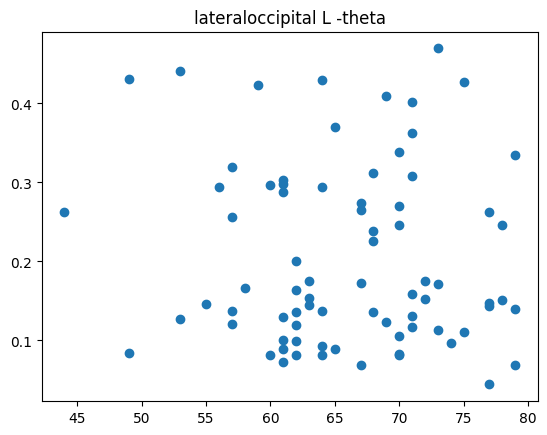

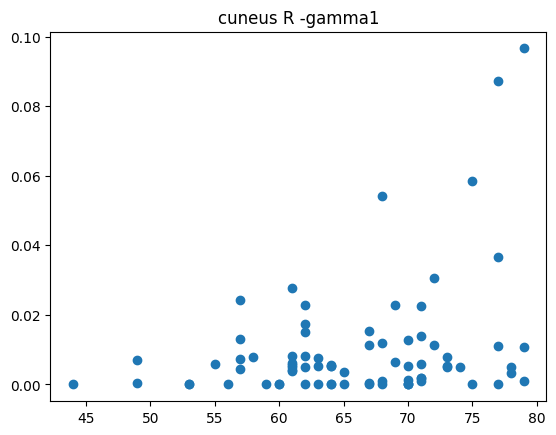

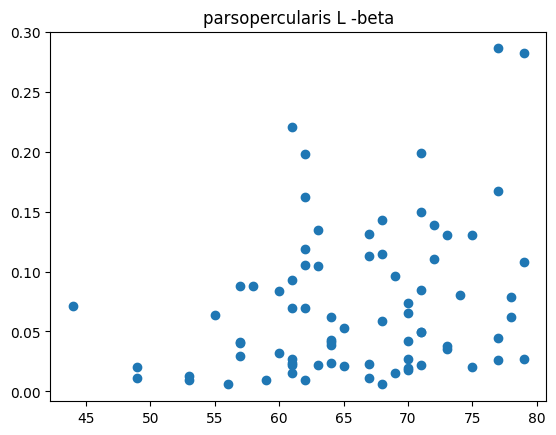

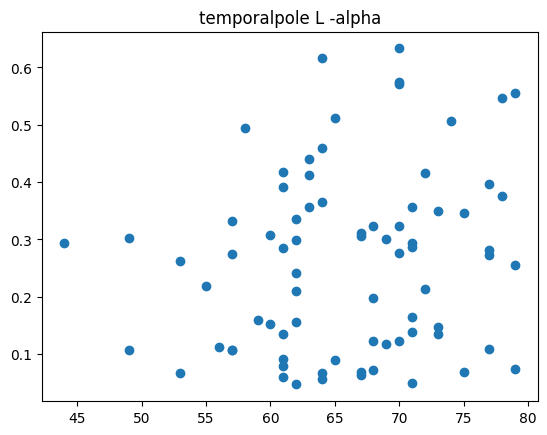

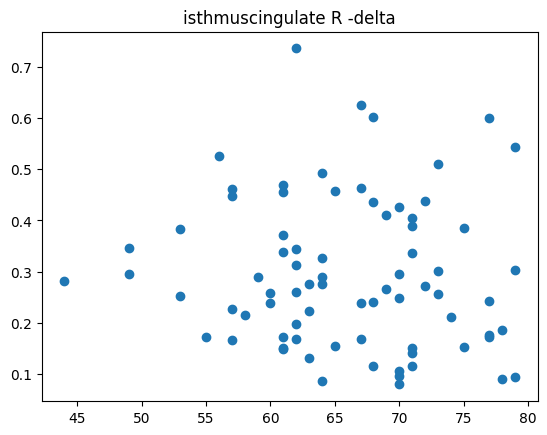

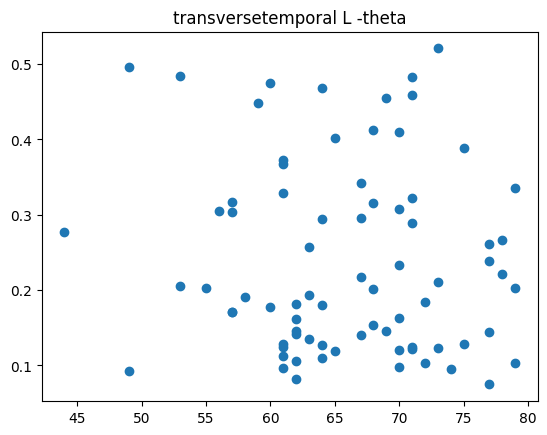

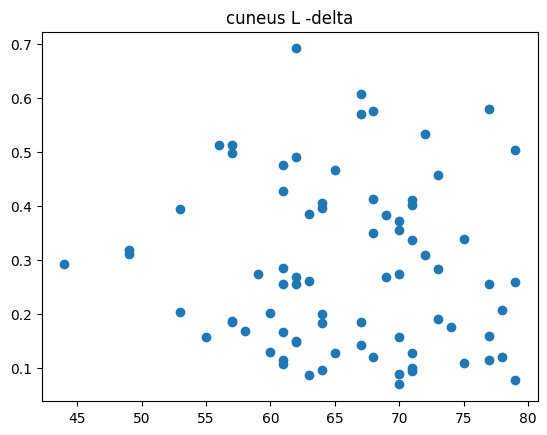

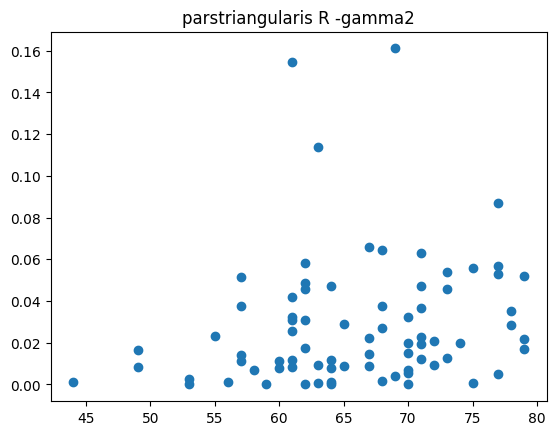

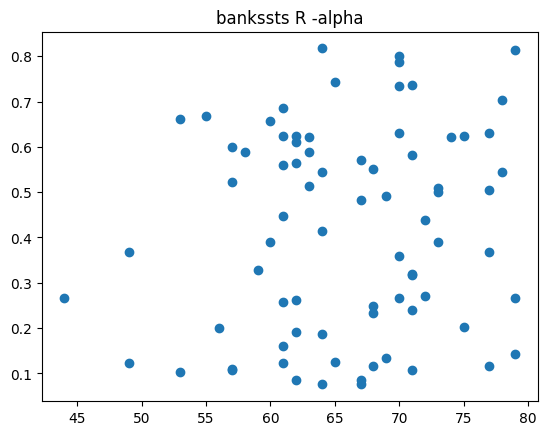

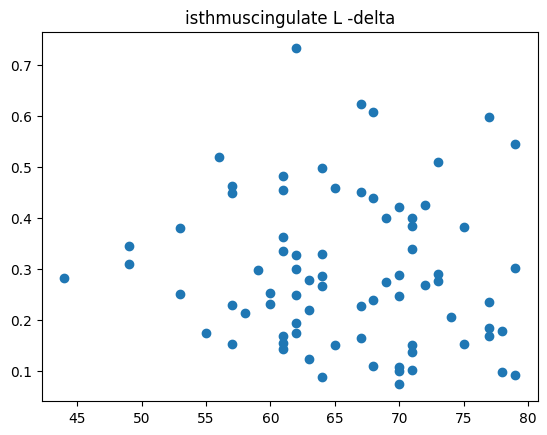

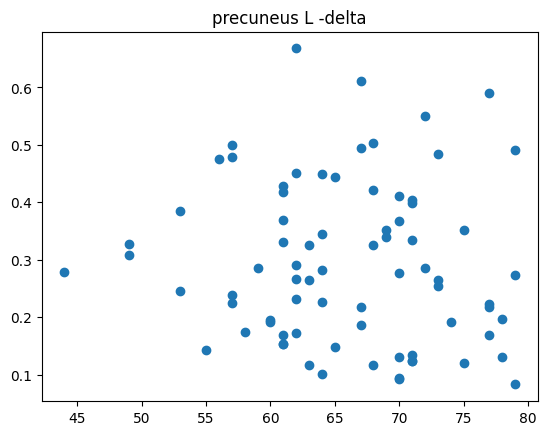

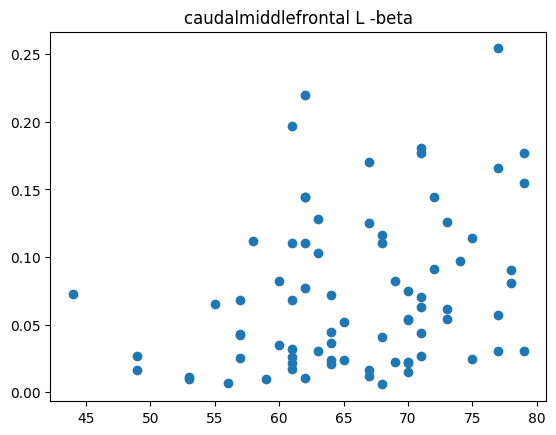

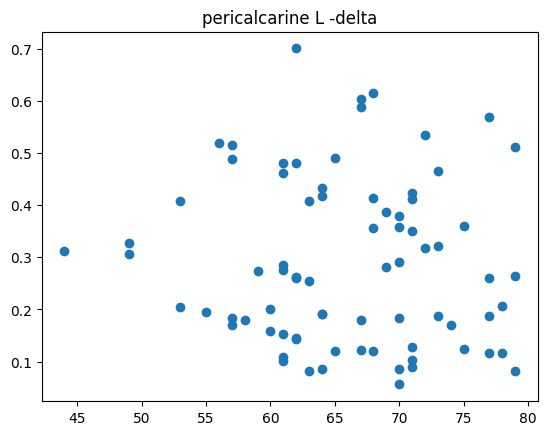

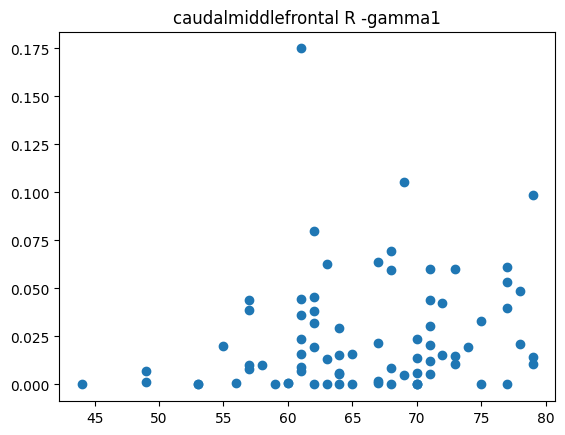

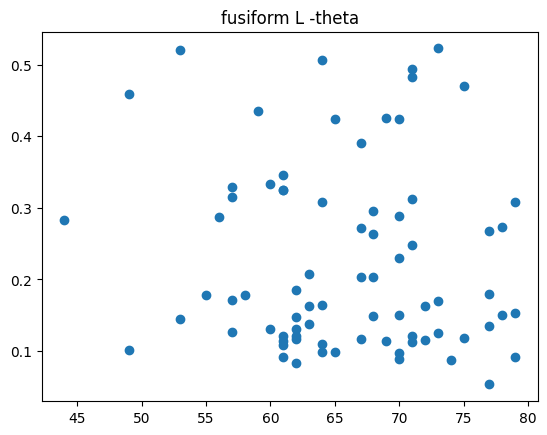

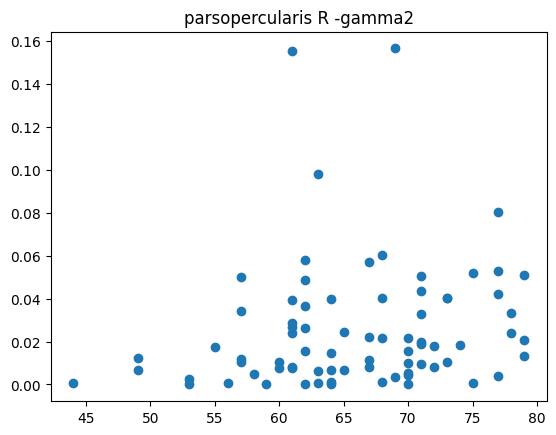

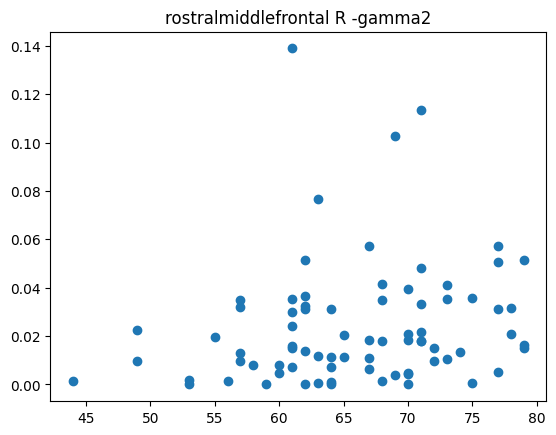

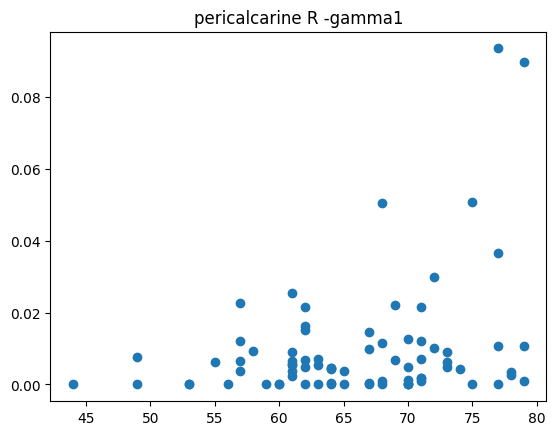

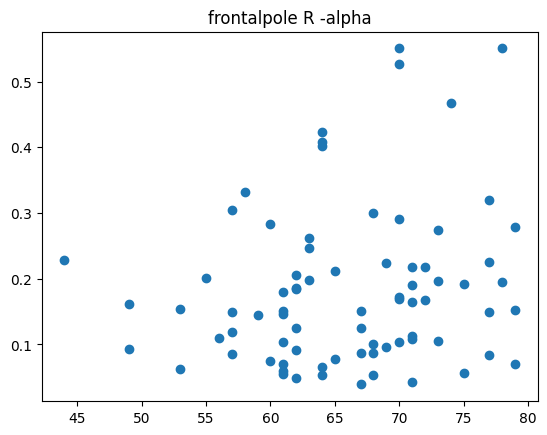

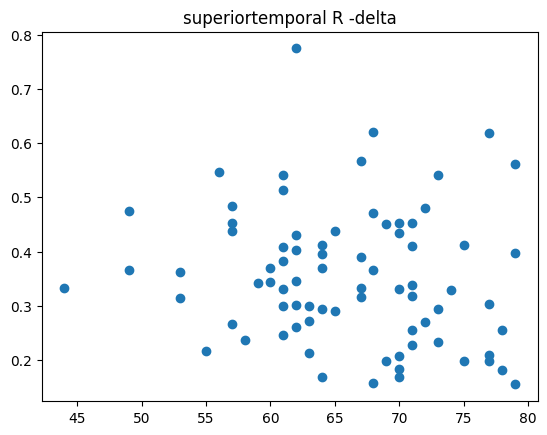

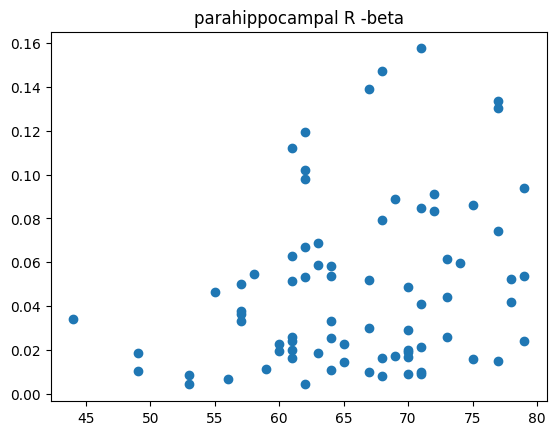

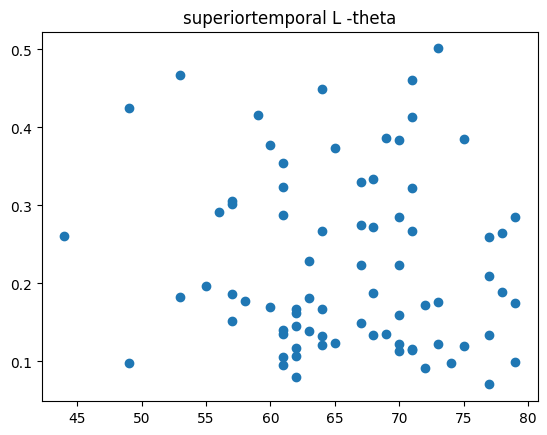

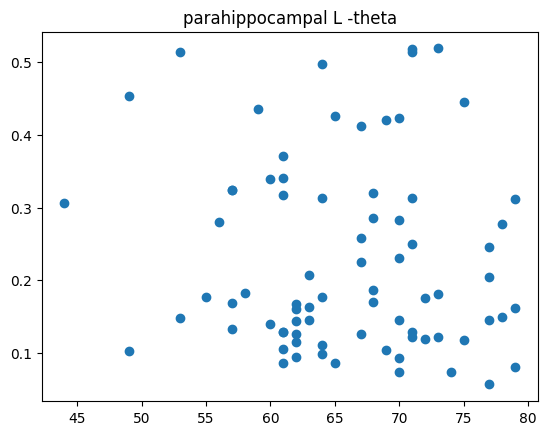

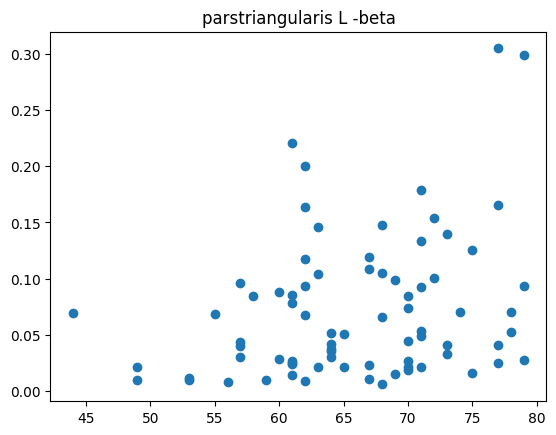

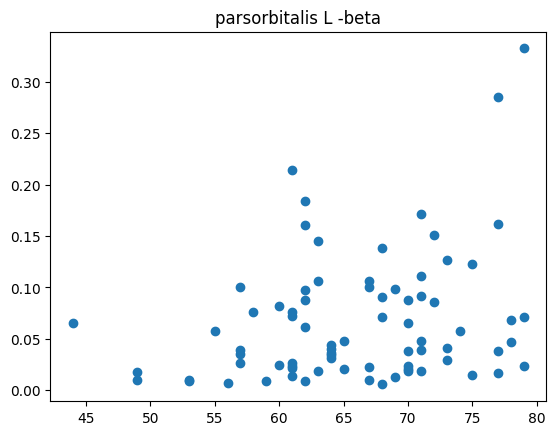

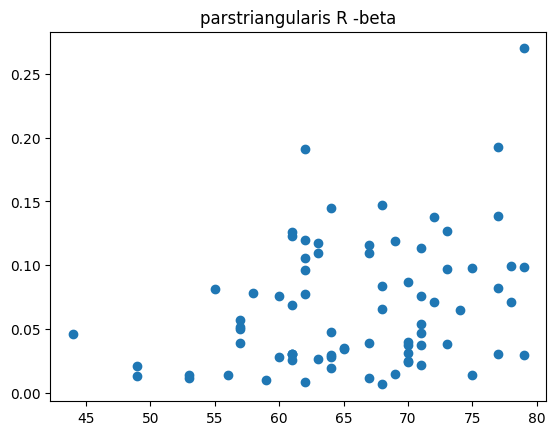

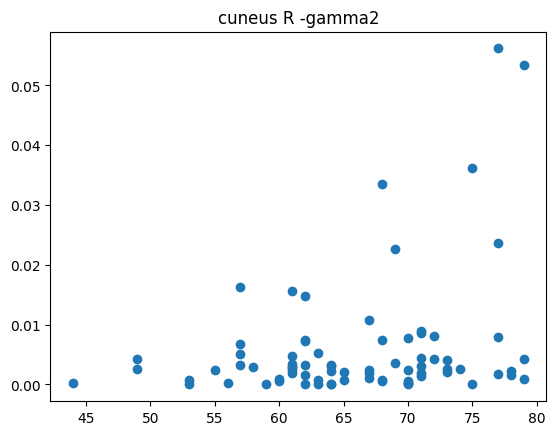

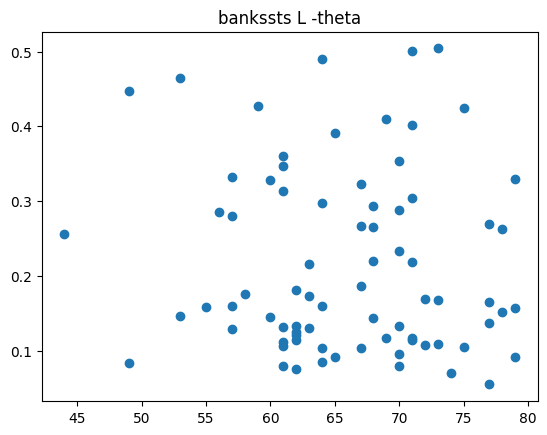

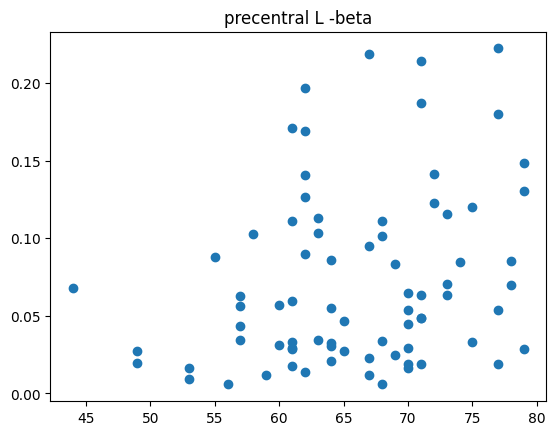

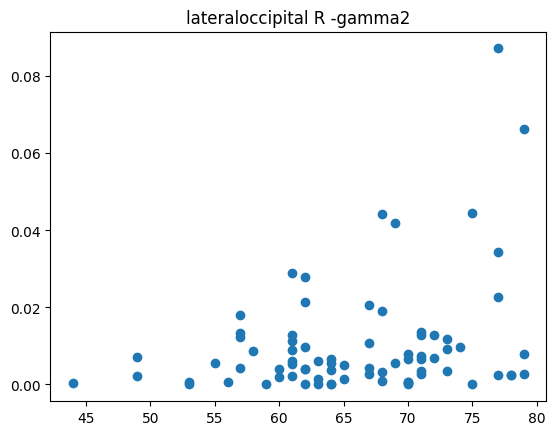

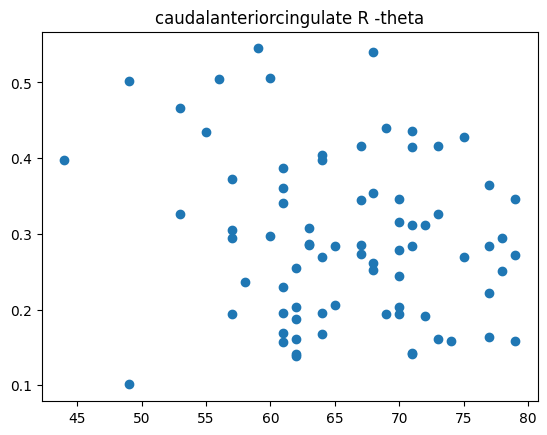

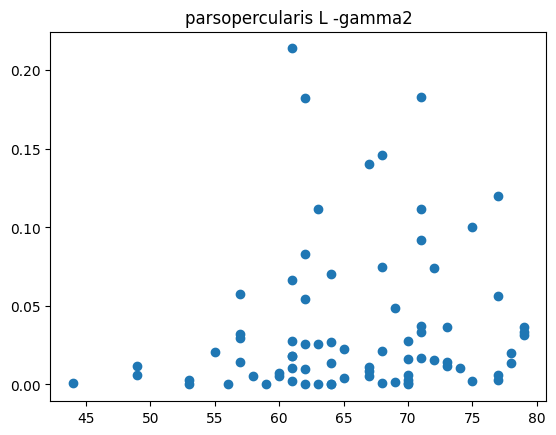

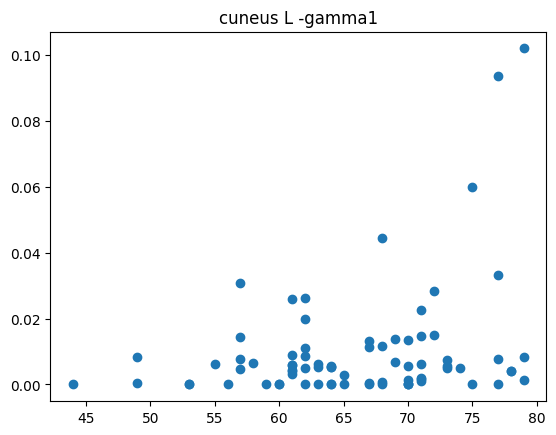

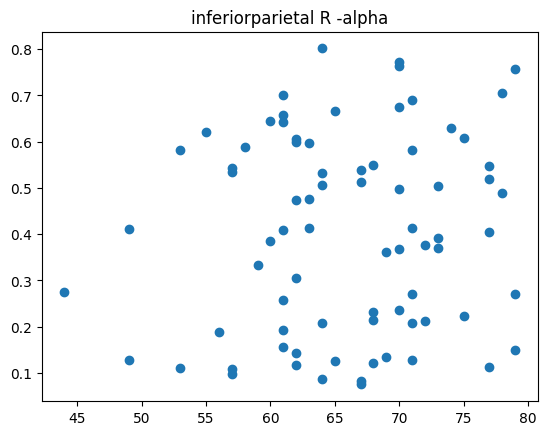

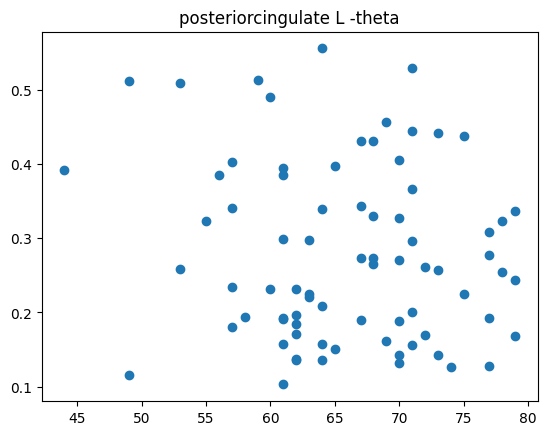

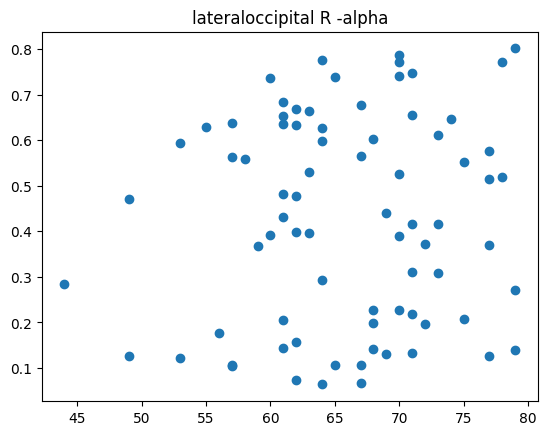

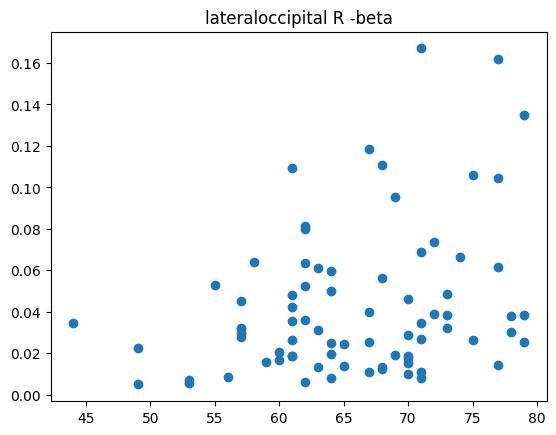

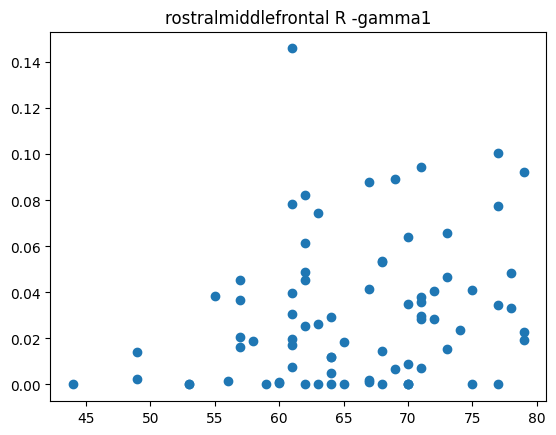

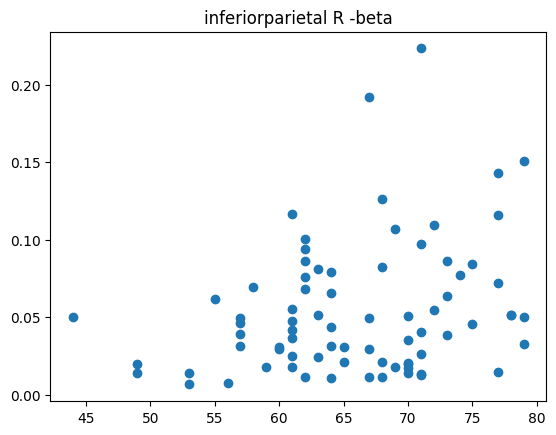

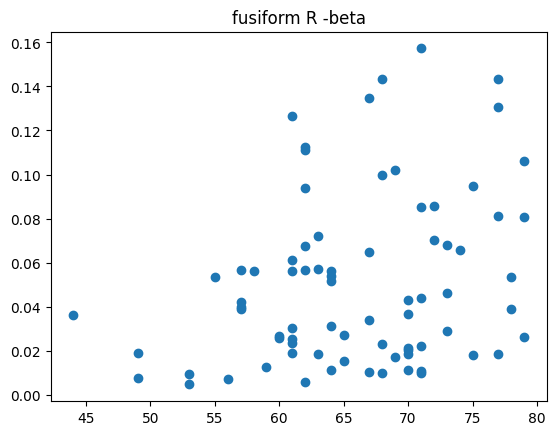

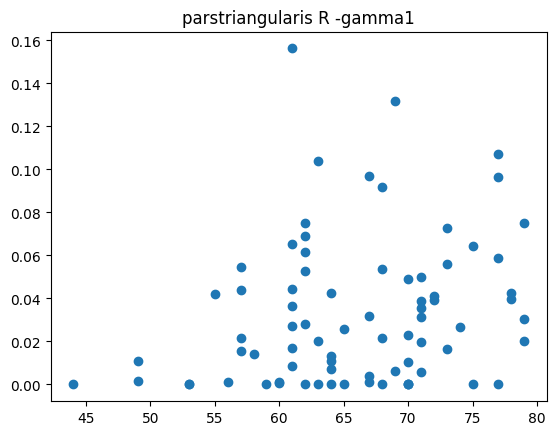

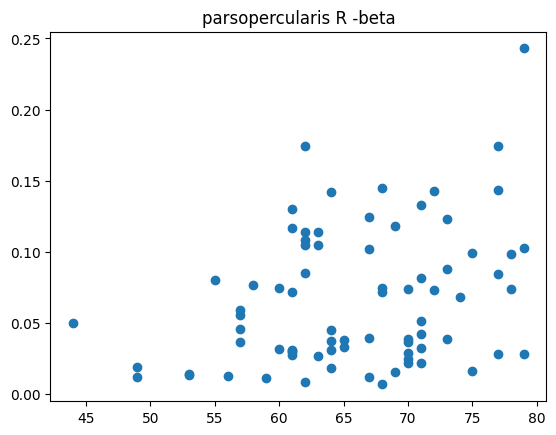

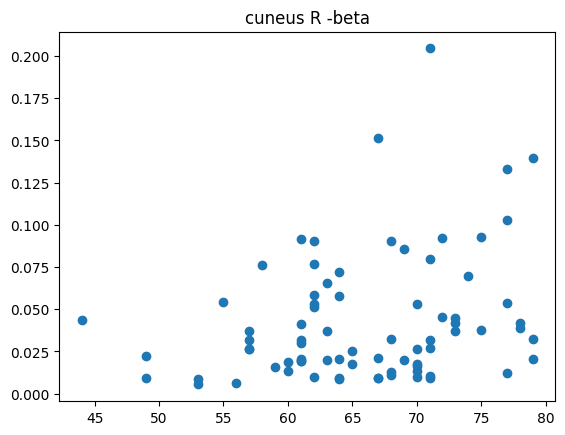

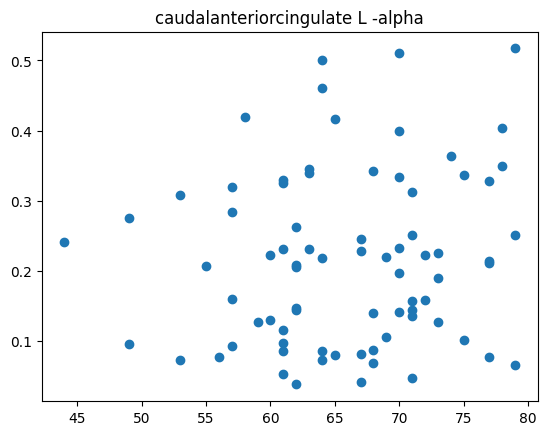

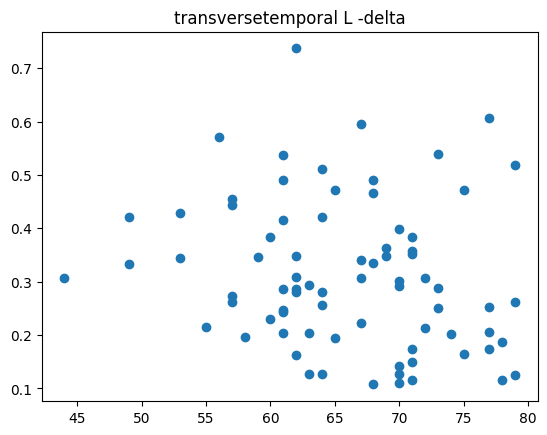

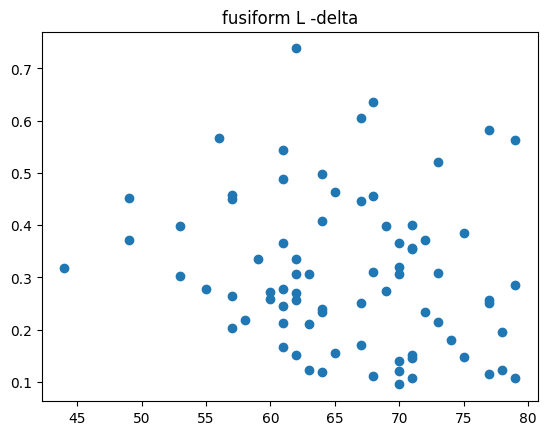

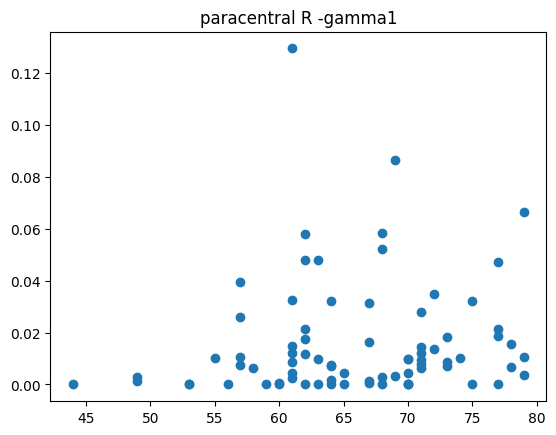

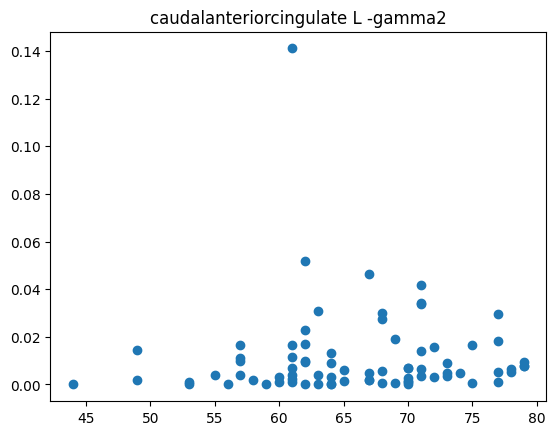

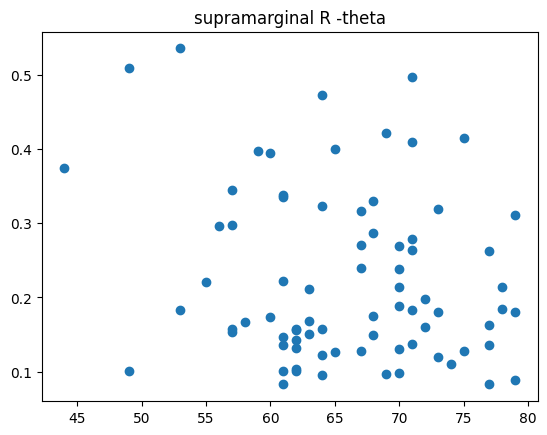

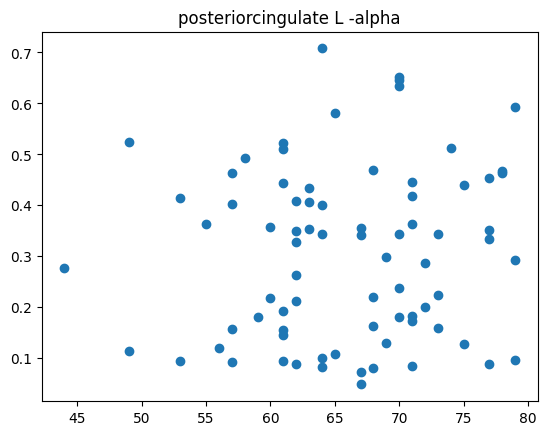

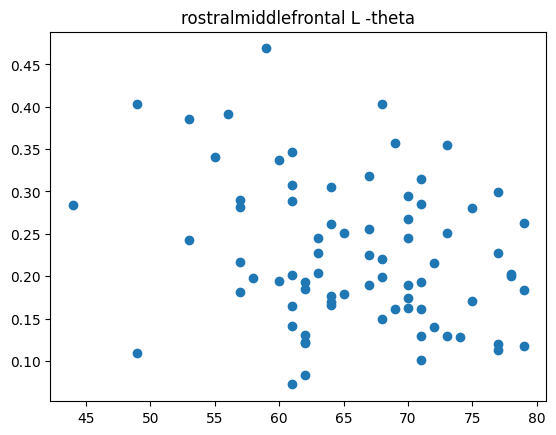

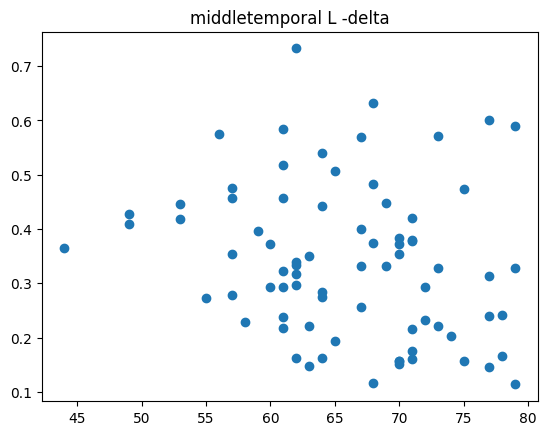

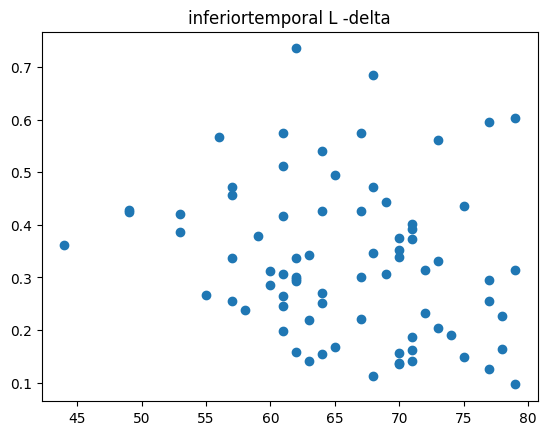

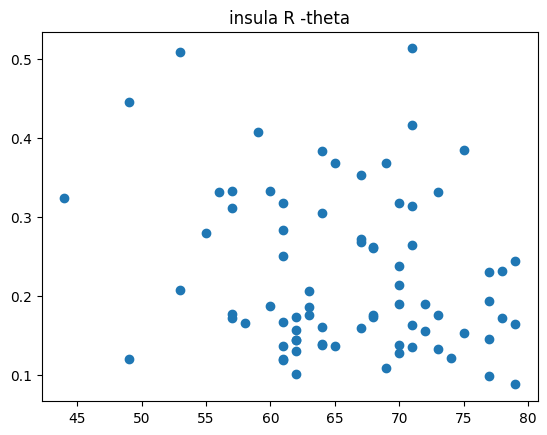

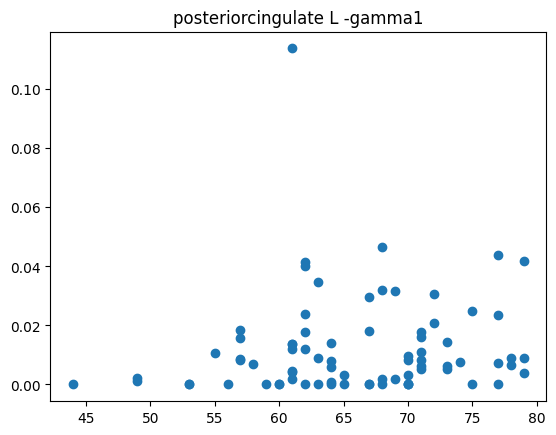

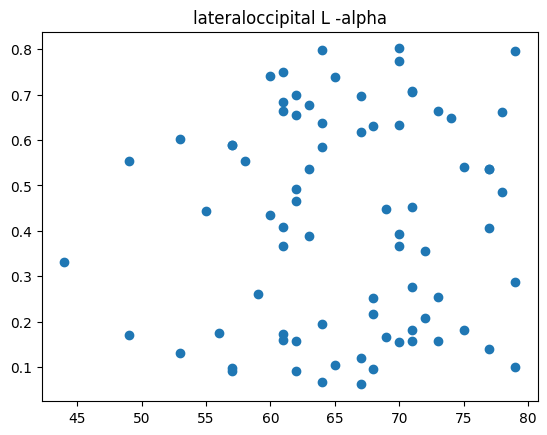

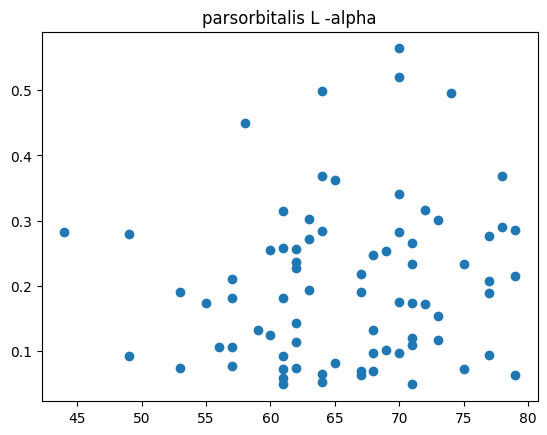

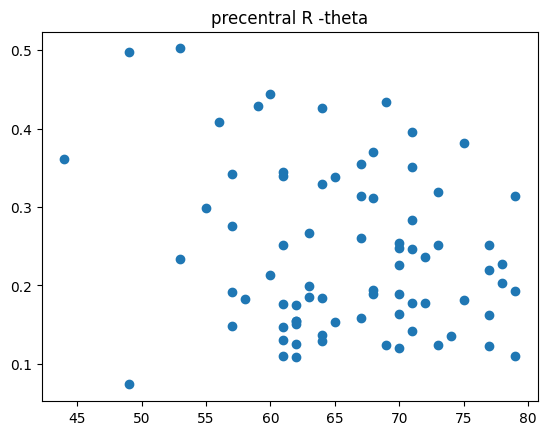

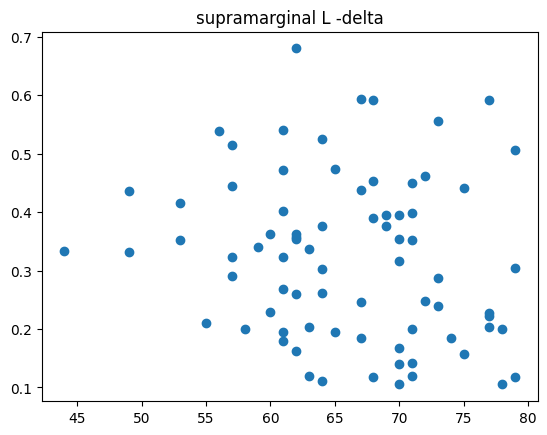

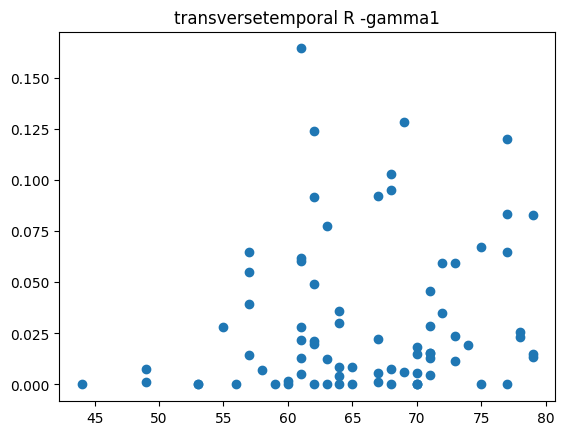

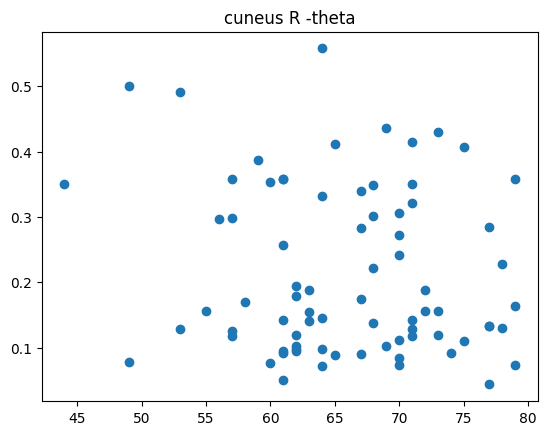

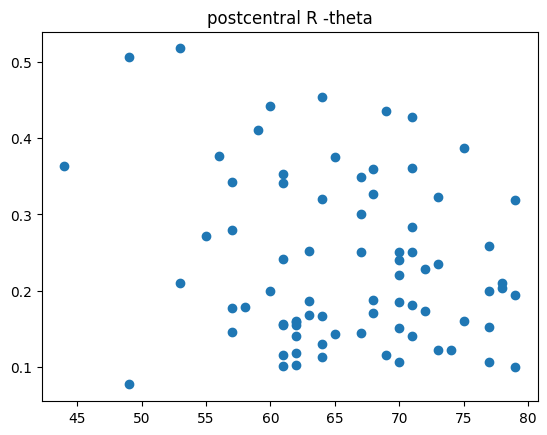

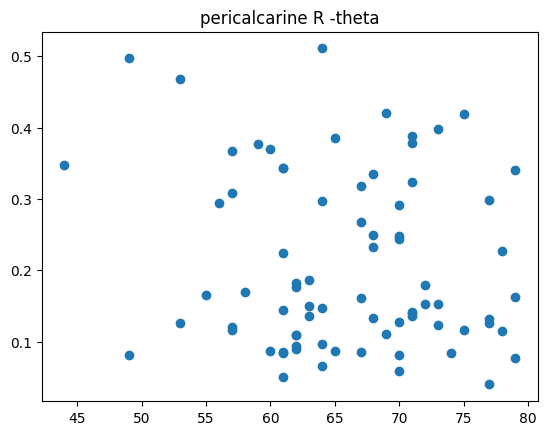

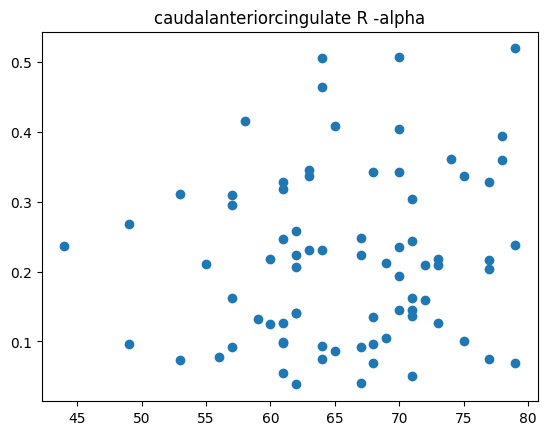

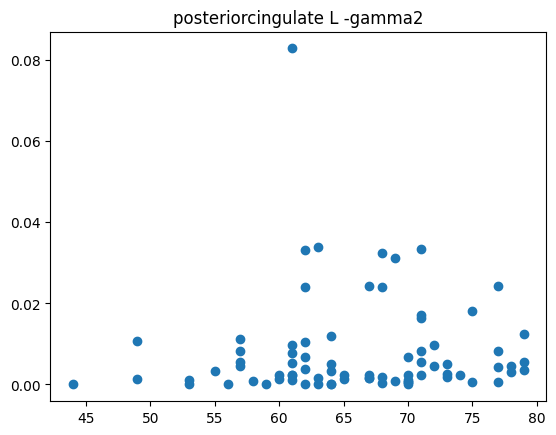

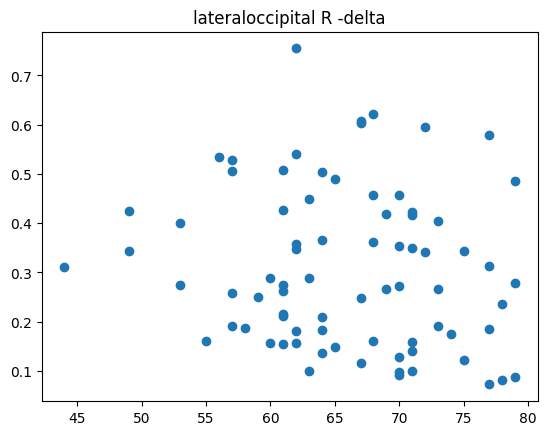

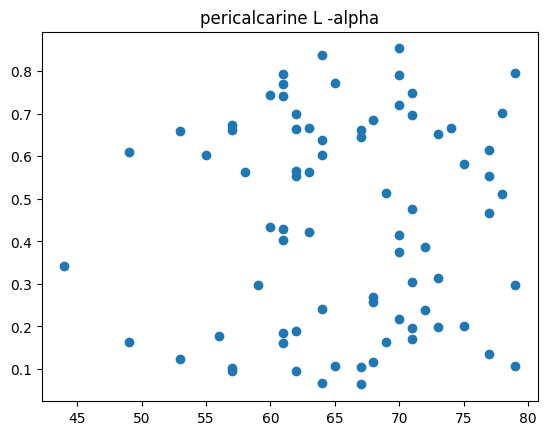

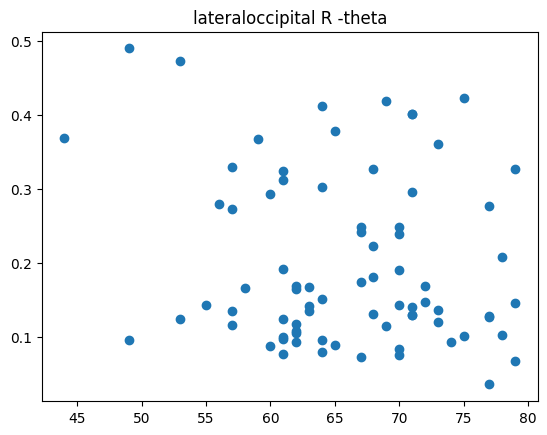

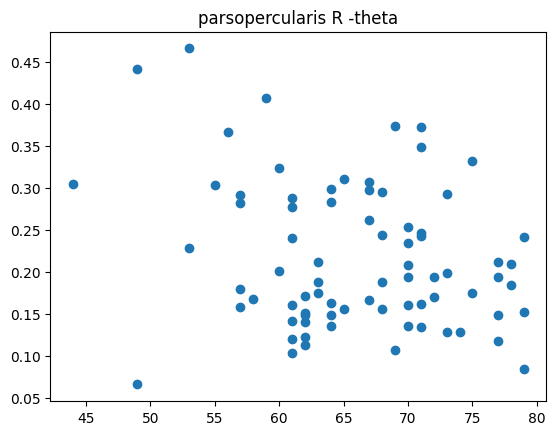

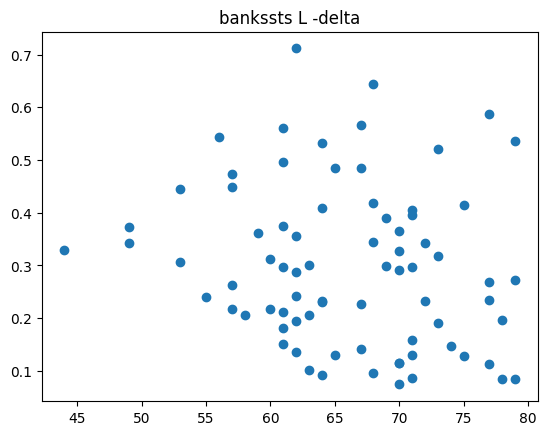

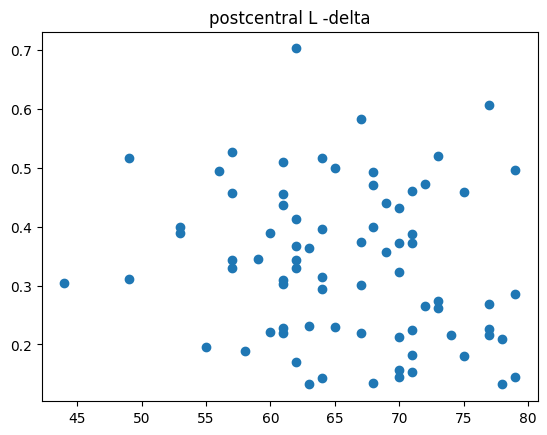

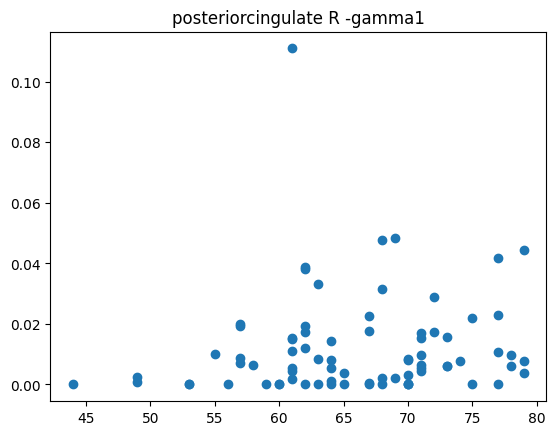

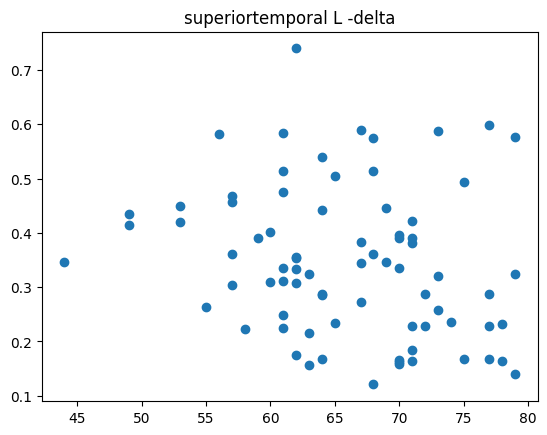

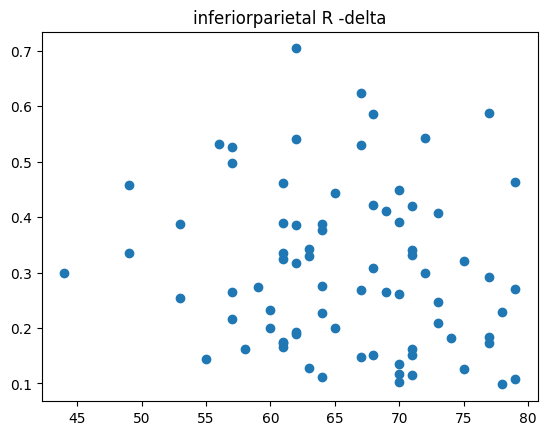

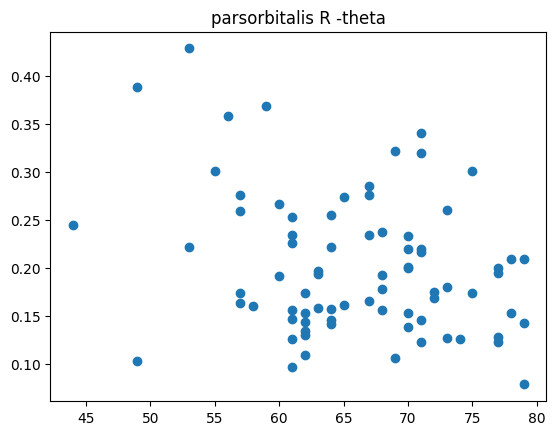

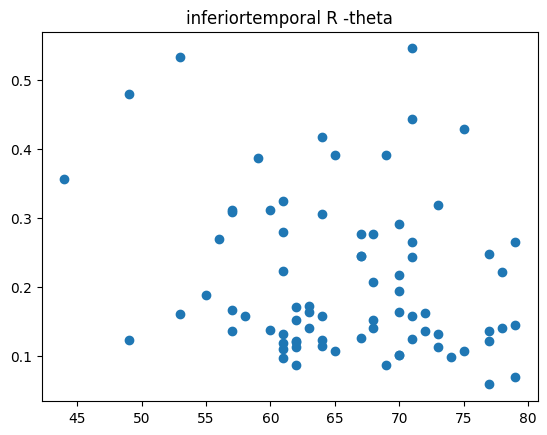

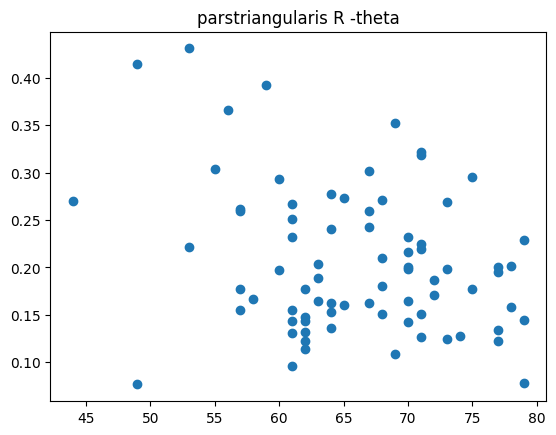

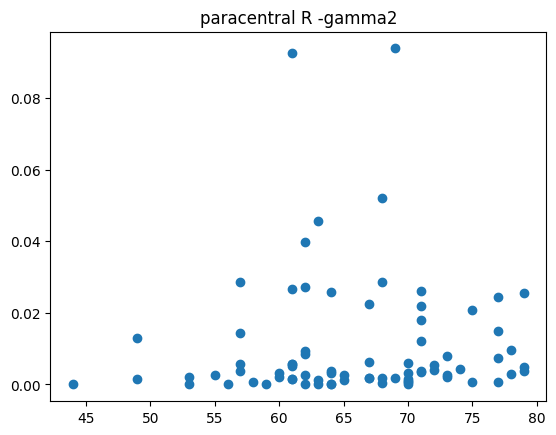

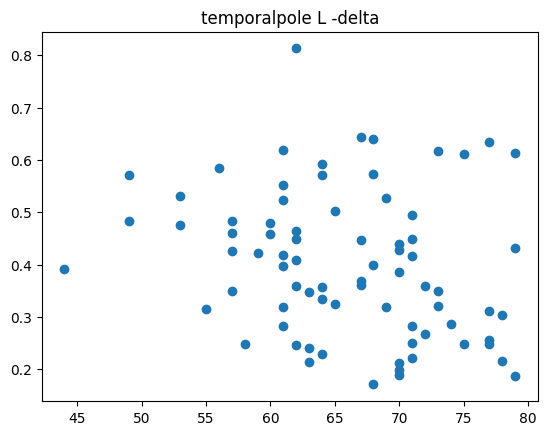

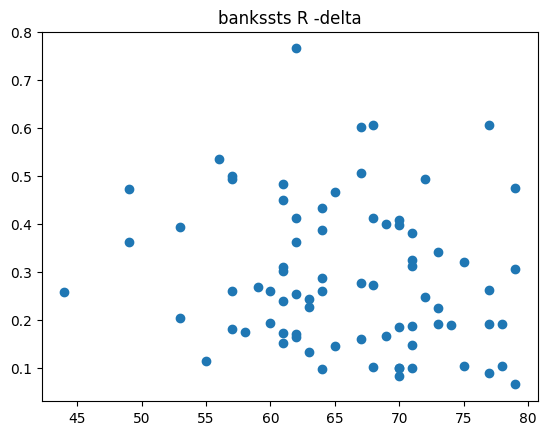

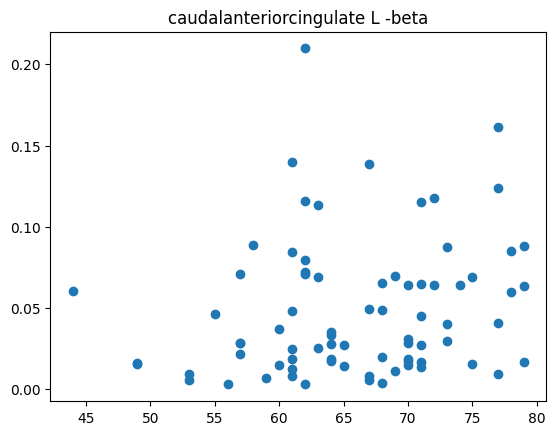

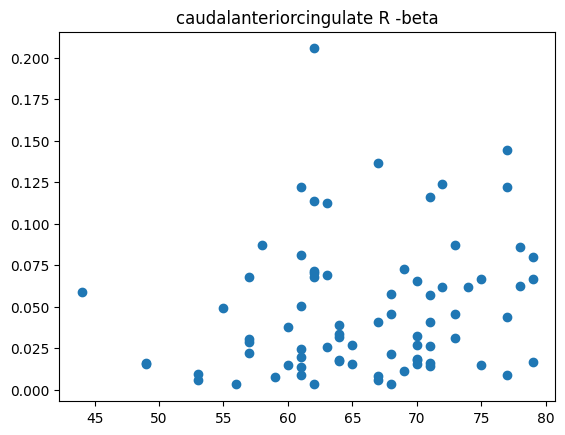

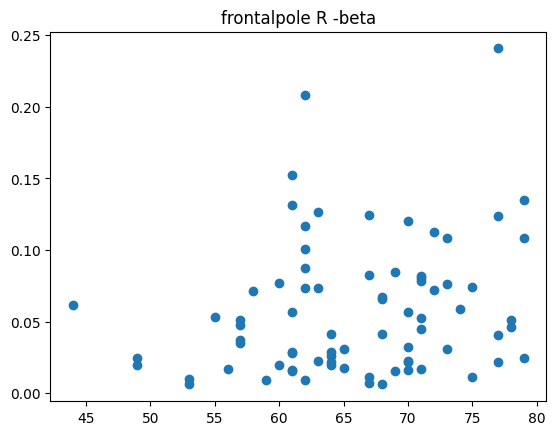

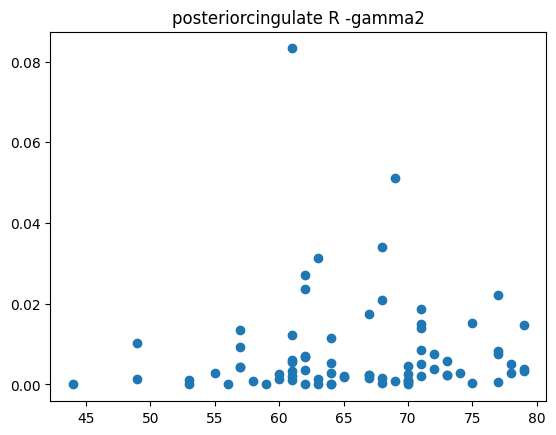

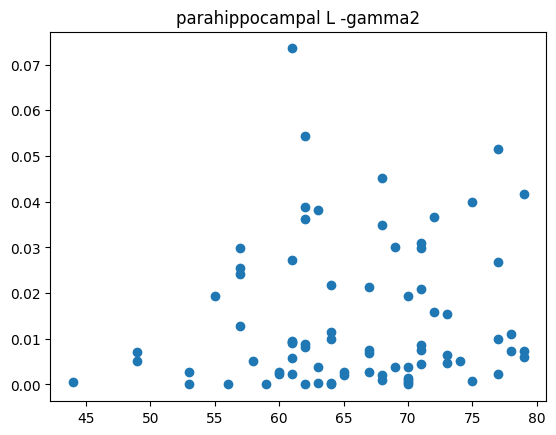

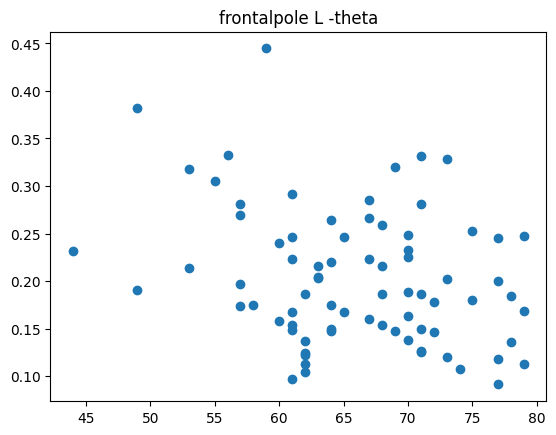

In [80]:
# Plot variation in each brain region with age
important_classes = important_features.Feature
important_indices = important_features.index

for i in range(len(important_indices)):
    plt.figure()
    plt.scatter(y, X[important_classes[important_indices[i]]])
    plt.title(important_classes[important_indices[i]])
